# AQI Predictor — Exploratory Data Analysis

Explores the feature-store data (`data/feature_store/aqi_features.parquet`) generated by `pipelines/backfill.py`, to motivate the feature engineering and modeling choices in `pipelines/training_pipeline.py`.

In [1]:
import sys
sys.path.append("..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/feature_store/aqi_features.parquet")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")
print(df.shape)
df.head()

(2040, 38)


,timestamp,pm2_5,pm10,ozone,no2,so2,co,us_aqi,temperature,humidity,...,aqi_roll_mean_6h,aqi_roll_std_6h,aqi_roll_mean_24h,aqi_roll_std_24h,aqi_change_rate_1h,aqi_change_rate_24h,target_aqi_24h,target_aqi_48h,target_aqi_72h,date
0,2026-06-03 00:00:00,44.4,76.7,26.6,18.5,10.1,305.9,78.0,10.2,65.0,...,108.333333,25.327587,120.687500,33.424130,-5.4,-10.7,73.8,76.3,80.1,2026-06-03 00:00:00
1,2026-06-03 01:00:00,53.1,84.7,27.6,18.0,7.4,329.8,91.5,10.3,69.2,...,99.583333,18.757976,121.545833,32.336814,13.5,20.6,76.7,80.0,65.3,2026-06-03 01:00:00
2,2026-06-03 02:00:00,43.5,75.4,31.1,15.5,6.5,294.3,75.4,10.1,63.5,...,91.633333,16.804126,121.787500,31.951095,-16.1,5.8,83.9,73.1,79.2,2026-06-03 02:00:00
3,2026-06-03 03:00:00,58.2,69.7,41.6,13.5,8.7,240.3,85.0,11.4,62.3,...,85.833333,9.598889,121.604167,32.156972,9.6,-4.4,74.7,84.4,78.1,2026-06-03 03:00:00
4,2026-06-03 04:00:00,45.2,68.5,9.6,33.2,6.1,260.9,72.6,16.0,53.4,...,80.983333,6.970342,121.500000,32.317810,-12.4,-2.5,83.1,86.1,69.2,2026-06-03 04:00:00


## 1. AQI distribution & EPA categories

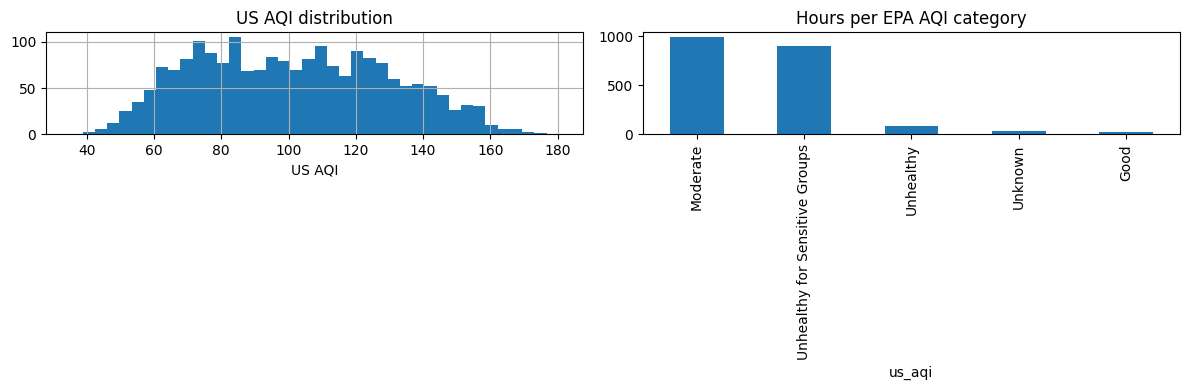

In [2]:
from utils.aqi_levels import classify_aqi

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["us_aqi"].hist(bins=40, ax=ax[0])
ax[0].set_title("US AQI distribution")
ax[0].set_xlabel("US AQI")

cat_counts = df["us_aqi"].apply(lambda v: classify_aqi(v)["category"]).value_counts()
cat_counts.plot(kind="bar", ax=ax[1])
ax[1].set_title("Hours per EPA AQI category")
plt.tight_layout()
plt.show()

## 2. Diurnal pattern — rush-hour pollution bumps

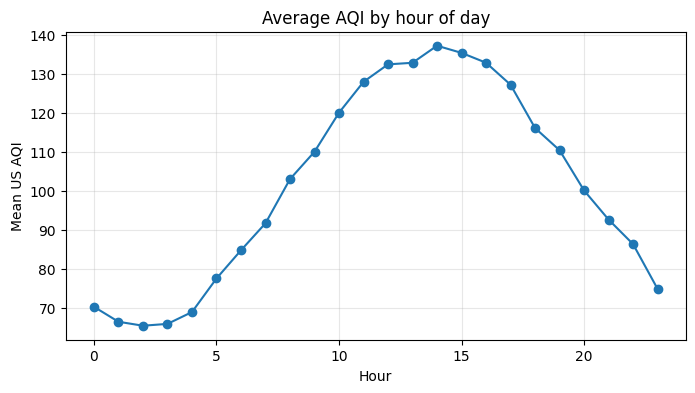

In [3]:
hourly_avg = df.groupby("hour")["us_aqi"].mean()
hourly_avg.plot(figsize=(8, 4), marker="o")
plt.title("Average AQI by hour of day")
plt.xlabel("Hour")
plt.ylabel("Mean US AQI")
plt.grid(alpha=0.3)
plt.show()

## 3. Weekday vs weekend

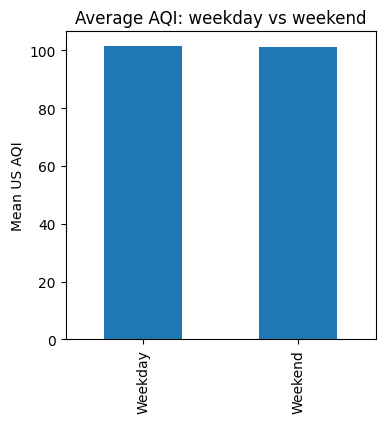

In [4]:
weekend_avg = df.groupby("is_weekend")["us_aqi"].mean()
weekend_avg.index = ["Weekday", "Weekend"]
weekend_avg.plot(kind="bar", figsize=(4, 4))
plt.title("Average AQI: weekday vs weekend")
plt.ylabel("Mean US AQI")
plt.show()

## 4. Correlation between weather variables and AQI

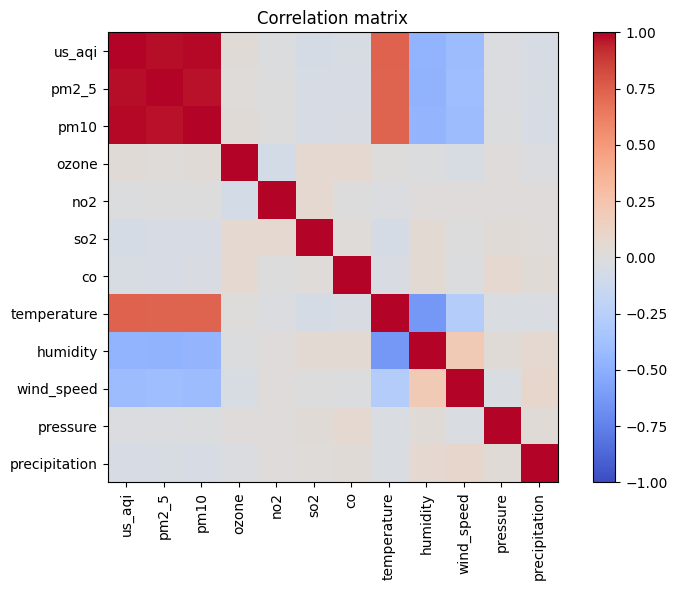

us_aqi           1.000000
pm10             0.988756
pm2_5            0.983961
temperature      0.740743
ozone            0.028199
no2             -0.009556
pressure        -0.017852
co              -0.045090
precipitation   -0.052519
so2             -0.055829
wind_speed      -0.407205
humidity        -0.465805
Name: us_aqi, dtype: float64

In [5]:
corr_cols = ["us_aqi", "pm2_5", "pm10", "ozone", "no2", "so2", "co",
             "temperature", "humidity", "wind_speed", "pressure", "precipitation"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=90)
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
fig.colorbar(im)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

corr["us_aqi"].sort_values(ascending=False)

**Observation:** wind speed tends to be negatively correlated with AQI (pollution disperses), while PM2.5/PM10 are (by construction) tightly coupled to US AQI — this motivates including wind speed and pressure as predictive features even though they aren't pollutants themselves.

## 5. Autocorrelation — why lag features matter

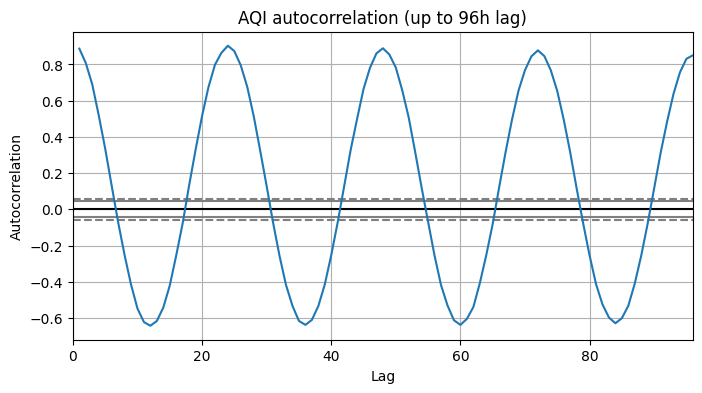

In [6]:
from pandas.plotting import autocorrelation_plot

fig, ax = plt.subplots(figsize=(8, 4))
autocorrelation_plot(df["us_aqi"].dropna().reset_index(drop=True), ax=ax)
ax.set_xlim(0, 96)
plt.title("AQI autocorrelation (up to 96h lag)")
plt.show()

AQI is strongly autocorrelated at 24h intervals (daily cycle), which is why `aqi_lag_24h`, `aqi_lag_48h`, and `aqi_lag_72h` — matched to the forecast horizons themselves — are included as features in `utils/features.py`.